In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn import tree
import graphviz
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
# Set random seed for reproducibility
np.random.seed(42)




## 🌸 Iris Dataset Overview

The **Iris dataset** is a classic dataset used in machine learning and statistics, introduced by **Ronald A. Fisher** in 1936. It is widely used for **classification**, **clustering**, and **data visualization** tasks.

### 📊 Features

The dataset contains **150 samples** from **three species** of the *Iris* flower:

* **Iris setosa**
* **Iris versicolor**
* **Iris virginica**

Each sample includes **four numerical features**:

| Feature        | Description  | Unit |
| -------------- | ------------ | ---- |
| `sepal_length` | Sepal length | cm   |
| `sepal_width`  | Sepal width  | cm   |
| `petal_length` | Petal length | cm   |
| `petal_width`  | Petal width  | cm   |

---

### 🏷️ Target Classes

| Class Index | Species    |
| ----------- | ---------- |
| 0           | setosa     |
| 1           | versicolor |
| 2           | virginica  |

---

### 🔢 Dataset Summary

* **Samples**: 150
* **Features**: 4 (all continuous)
* **Classes**: 3
* **Balanced**: Yes (50 samples per class)

---

### 🧠 Common Use Cases

* Supervised learning (classification)
* Unsupervised learning (clustering)
* Dimensionality reduction (e.g., PCA)
* Data visualization



## 🔐 FHE Test Setup with Iris Dataset

This notebook serves as a **testbed for Fully Homomorphic Encryption (FHE)** logic.

* The original **Iris dataset** will be **normalized** to the range **\[-1, +1]** for all input features.
* This normalization ensures inputs stay within the safe and efficient evaluation range for encrypted polynomial functions.
* **No input will ever exceed the interval \[-2, +2]**, preserving numerical stability and correctness of sigmoid-based logic.

---

### 🎯 Objective

We aim to simulate **conditional logic** (e.g., decision tree traversal) using **polynomial approximations of the sigmoid function**. These polynomials allow encrypted evaluation of "soft" comparisons without branching.

* **Degree-1 Polynomial**:

  $$
  P₁(x) ≈ 0.5 + 0.1966x
  $$

  Simple and lightweight, ideal for low-depth logic.

* **Degree-3 Polynomial**:

  $$
  P₃(x) ≈ 0.5 + 0.2159x - 0.0082x³
  $$

  Provides sharper transitions, better mimicking threshold conditions.

---

### 🌳 Simulating Tree Traversal

In a normal decision tree, traversal depends on **if-else conditions** like:

```python
if x[feature_index] < threshold:
    go left
else:
    go right
```

In encrypted FHE logic (no branching), we approximate this using a **sigmoid polynomial** to compute a **soft binary gate**:

$$
\text{gate}(x) = \text{sigmoid\_poly}(x_{\text{feature}} - \text{threshold})
$$

This gate acts like:

* Close to `0` when the condition is **false**
* Close to `1` when the condition is **true**

We then **blend left and right subtree results** using this gate:

$$
\text{result} = \text{gate} \cdot \text{right\_value} + (1 - \text{gate}) \cdot \text{left\_value}
$$

This allows **tree traversal without branching**, entirely within polynomial arithmetic — ideal for FHE environments.



In [3]:
# ## 2. Load and normalize the IRIS dataset

# Load the iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Normalize the data to range [-1, +1] using MinMaxScaler
scaler = MinMaxScaler(feature_range=(-1, 1))
X_normalized = scaler.fit_transform(X)

# Convert to DataFrame for easier exploration
iris_df = pd.DataFrame(data=X_normalized, columns=feature_names)
iris_df['target'] = y
iris_df['species'] = iris_df['target'].apply(lambda x: target_names[x])

# Display the first few rows of the normalized dataset
print("First 5 rows of the normalized IRIS dataset:")
print(iris_df.head())

# Verify normalization range
print("\nVerifying normalization range:")
print("Min values:", np.min(X_normalized, axis=0))
print("Max values:", np.max(X_normalized, axis=0))

# Basic dataset information
print("\nBasic dataset information:")
print(f"Number of samples: {X_normalized.shape[0]}")
print(f"Number of features: {X_normalized.shape[1]}")
print(f"Features: {feature_names}")
print(f"Target classes: {target_names}")
print(f"Class distribution: {np.bincount(y)}")



First 5 rows of the normalized IRIS dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.555556          0.250000          -0.864407         -0.916667   
1          -0.666667         -0.166667          -0.864407         -0.916667   
2          -0.777778          0.000000          -0.898305         -0.916667   
3          -0.833333         -0.083333          -0.830508         -0.916667   
4          -0.611111          0.333333          -0.864407         -0.916667   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

Verifying normalization range:
Min values: [-1. -1. -1. -1.]
Max values: [1. 1. 1. 1.]

Basic dataset information:
Number of samples: 150
Number of features: 4
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']
Class distribution: [50 50 50]


Training set size: 105 samples
Testing set size: 45 samples


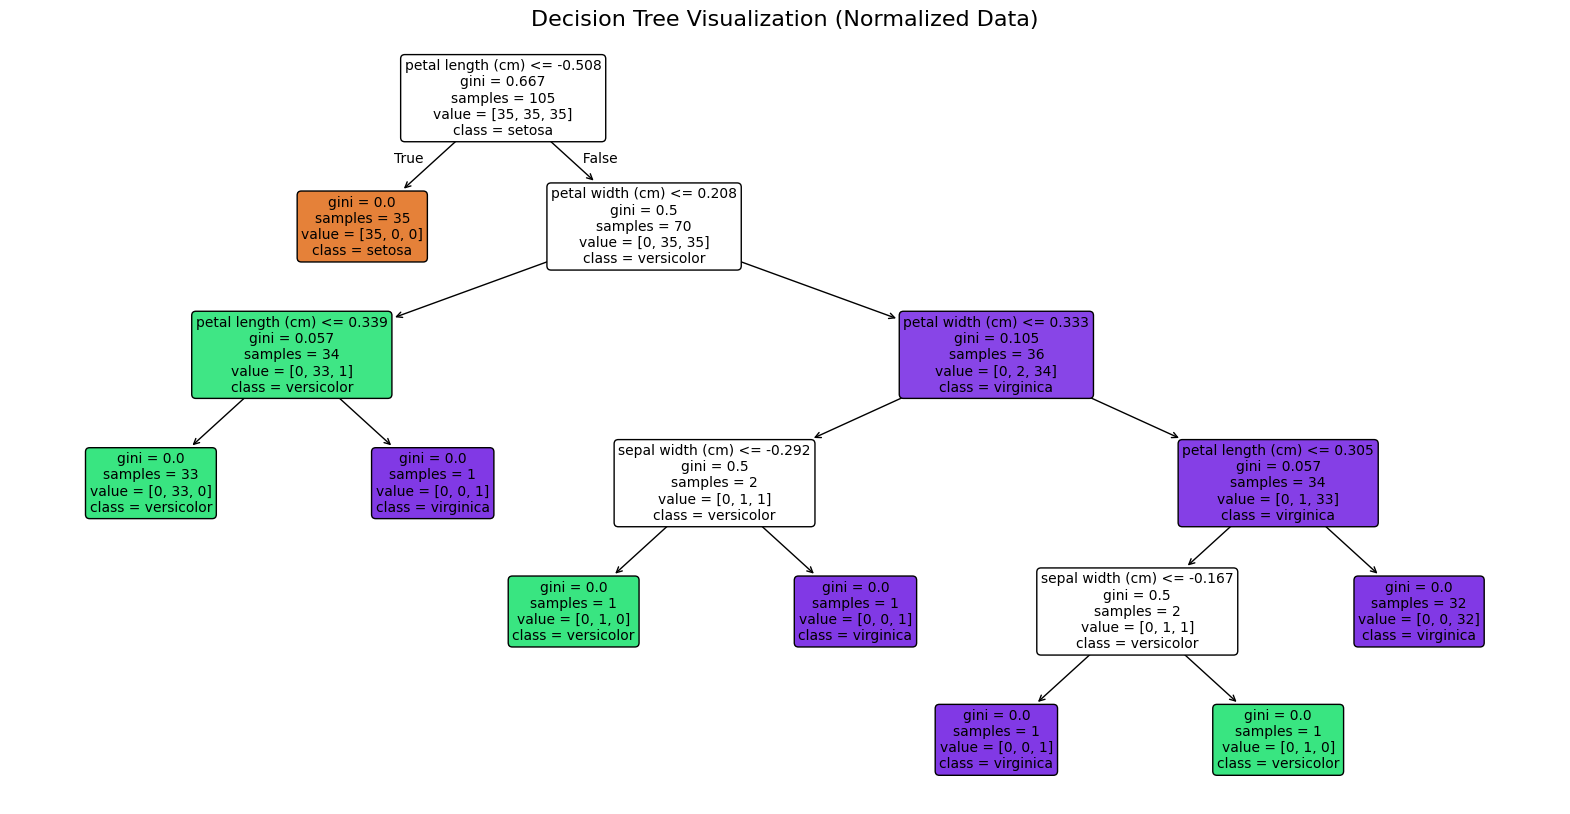

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# ## 5. Train a Decision Tree Classifier

# Initialize the classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the model
dt_classifier.fit(X_train, y_train)

# ## 6. Visualize the Decision Tree

plt.figure(figsize=(20, 10))
tree.plot_tree(dt_classifier, feature_names=feature_names, class_names=target_names, 
               filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Visualization (Normalized Data)", fontsize=16)
plt.show()


Decision Tree Parameters:
Criterion: gini
Splitter: best
Max Depth: None
Min Samples Split: 2
Min Samples Leaf: 1
Max Features: None
Tree Depth: 5
Number of Leaves: 8
Feature Importances: [0.         0.02857143 0.54117647 0.4302521 ]

Feature Importance:
             Feature  Importance
2  petal length (cm)    0.541176
3   petal width (cm)    0.430252
1   sepal width (cm)    0.028571
0  sepal length (cm)    0.000000

Model Evaluation:
Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45


Confusion Matrix:


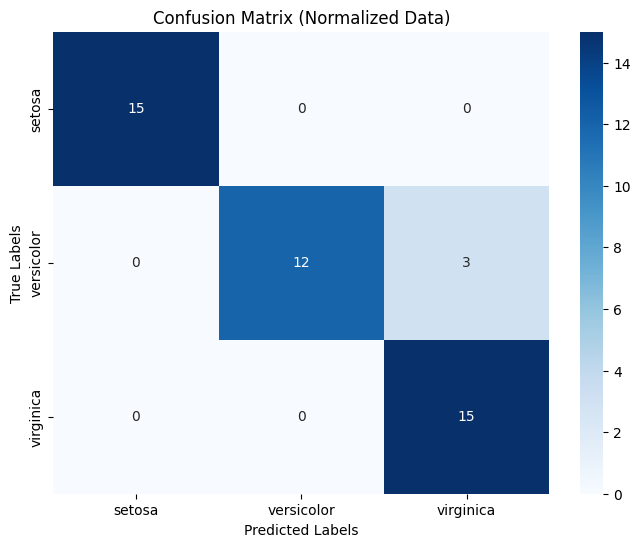

In [5]:
# ## 7. Make predictions and evaluate the model

y_pred = dt_classifier.predict(X_test)

# Print model parameters
print("\nDecision Tree Parameters:")
print(f"Criterion: {dt_classifier.criterion}")
print(f"Splitter: {dt_classifier.splitter}")
print(f"Max Depth: {dt_classifier.max_depth}")
print(f"Min Samples Split: {dt_classifier.min_samples_split}")
print(f"Min Samples Leaf: {dt_classifier.min_samples_leaf}")
print(f"Max Features: {dt_classifier.max_features}")
print(f"Tree Depth: {dt_classifier.get_depth()}")
print(f"Number of Leaves: {dt_classifier.get_n_leaves()}")
print(f"Feature Importances: {dt_classifier.feature_importances_}")

# Print feature importance with feature names
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# ## 8. Evaluate model performance

print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (Normalized Data)')
plt.show()



Model Evaluation:
Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45


Confusion Matrix:


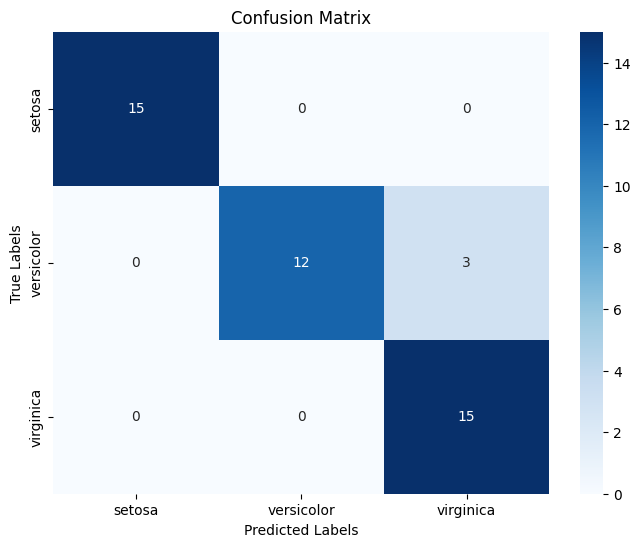

In [6]:
# ## 8. Evaluate model performance

print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()



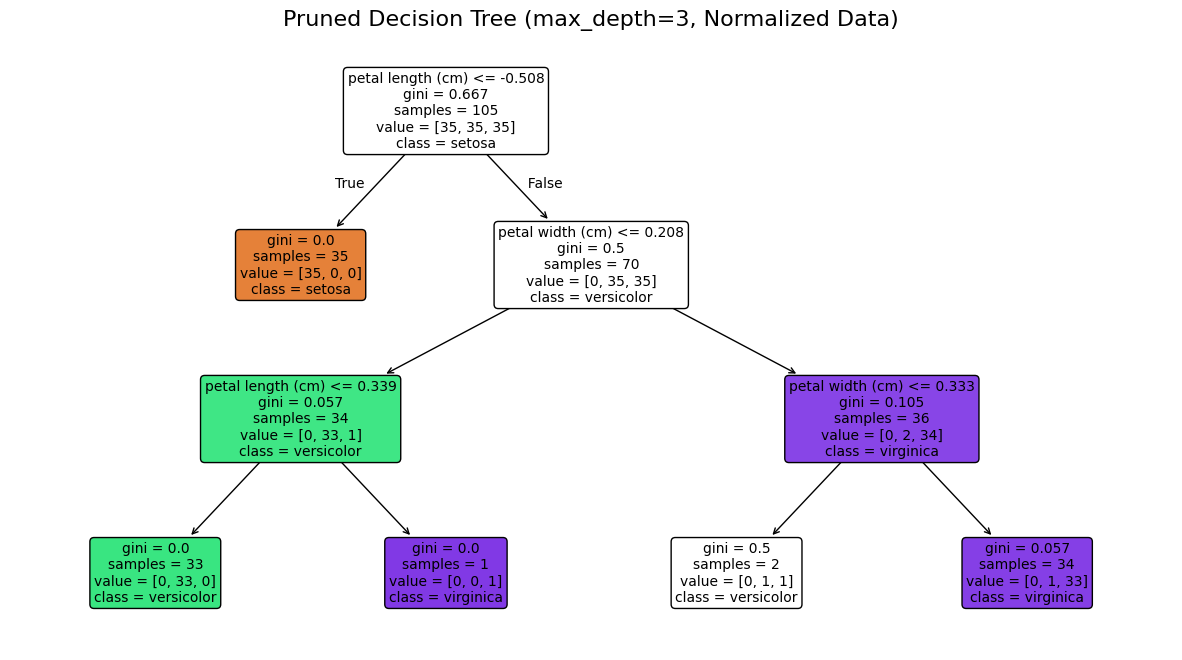


Pruned Decision Tree Evaluation:
Accuracy: 0.9778

Classification Report (Pruned Tree):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [7]:
# ## 9. Try different parameters to improve the model

# Let's create a decision tree with controlled depth to avoid overfitting
dt_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_pruned.fit(X_train, y_train)

# Visualize the pruned tree
plt.figure(figsize=(15, 8))
tree.plot_tree(dt_pruned, feature_names=feature_names, class_names=target_names, 
               filled=True, rounded=True, fontsize=10)
plt.title("Pruned Decision Tree (max_depth=3, Normalized Data)", fontsize=16)
plt.show()

# Evaluate the pruned model
y_pred_pruned = dt_pruned.predict(X_test)
print("\nPruned Decision Tree Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_pruned):.4f}")
print("\nClassification Report (Pruned Tree):")
print(classification_report(y_test, y_pred_pruned, target_names=target_names))


In [8]:
# ## 11. Conclusion

print("\nConclusion:")
print("We have successfully implemented a decision tree classifier on the normalized IRIS dataset.")
print("All features were scaled to the range [-1, +1] before training.")
print("The model achieved good accuracy in classifying the three species of iris flowers.")
print("We also visualized the decision tree and analyzed feature importance.")
print("The most important features for classification were:", 
      feature_names[np.argmax(dt_classifier.feature_importances_)])
print("\nNormalization effects:")
print("- Ensures all features contribute equally to the decision process")
print("- Can improve model interpretability as feature scales are comparable")
print("- May change the structure of the decision tree compared to non-normalized data")



Conclusion:
We have successfully implemented a decision tree classifier on the normalized IRIS dataset.
All features were scaled to the range [-1, +1] before training.
The model achieved good accuracy in classifying the three species of iris flowers.
We also visualized the decision tree and analyzed feature importance.
The most important features for classification were: petal length (cm)

Normalization effects:
- Ensures all features contribute equally to the decision process
- Can improve model interpretability as feature scales are comparable
- May change the structure of the decision tree compared to non-normalized data


In [9]:
# Function to extract tree structure
def extract_tree_structure(tree_model):
    """
    Extract the structure of a decision tree as a dictionary.
    Each node contains information about the split and left/right children.
    """
    n_nodes = tree_model.tree_.node_count
    children_left = tree_model.tree_.children_left
    children_right = tree_model.tree_.children_right
    feature = tree_model.tree_.feature
    threshold = tree_model.tree_.threshold
    values = tree_model.tree_.value
    
    # Initialize tree structure
    tree_structure = {}
    
    # Extract information for each node
    for node_id in range(n_nodes):
        # If not a leaf node
        if children_left[node_id] != children_right[node_id]:
            tree_structure[node_id] = {
                'type': 'split',
                'feature_index': feature[node_id],
                'feature_name': feature_names[feature[node_id]],
                'threshold': threshold[node_id],
                'left_child': children_left[node_id],
                'right_child': children_right[node_id]
            }
        # If a leaf node
        else:
            # Get the majority class
            class_counts = values[node_id][0]
            majority_class = np.argmax(class_counts)
            
            tree_structure[node_id] = {
                'type': 'leaf',
                'class': majority_class,
                'class_name': target_names[majority_class],
                'class_counts': class_counts
            }
    
    return tree_structure

# Extract the tree structure
tree_structure = extract_tree_structure(dt_classifier)

# Function to print the tree structure in a readable format
def print_tree(tree_structure, node_id=0, depth=0):
    """Print the tree structure with indentation to show hierarchy."""
    node = tree_structure[node_id]
    indent = "  " * depth
    
    if node['type'] == 'split':
        print(f"{indent}Node {node_id}: {node['feature_name']} <= {node['threshold']:.4f}")
        print(f"{indent}├── Left (True) →")
        print_tree(tree_structure, node['left_child'], depth + 1)
        print(f"{indent}└── Right (False) →")
        print_tree(tree_structure, node['right_child'], depth + 1)
    else:  # leaf node
        counts = node['class_counts']
        total = sum(counts)
        percentages = [f"{count/total*100:.1f}%" for count in counts]
        counts_str = ", ".join([f"{target_names[i]}: {counts[i]} ({percentages[i]})" 
                              for i in range(len(counts)) if counts[i] > 0])
        print(f"{indent}Node {node_id}: Leaf → Predict {node['class_name']} [{counts_str}]")

# Print the tree structure
print("\nDECISION TREE STRUCTURE:")
print("========================\n")
print_tree(tree_structure)


DECISION TREE STRUCTURE:

Node 0: petal length (cm) <= -0.5085
├── Left (True) →
  Node 1: Leaf → Predict setosa [setosa: 1.0 (100.0%)]
└── Right (False) →
  Node 2: petal width (cm) <= 0.2083
  ├── Left (True) →
    Node 3: petal length (cm) <= 0.3390
    ├── Left (True) →
      Node 4: Leaf → Predict versicolor [versicolor: 1.0 (100.0%)]
    └── Right (False) →
      Node 5: Leaf → Predict virginica [virginica: 1.0 (100.0%)]
  └── Right (False) →
    Node 6: petal width (cm) <= 0.3333
    ├── Left (True) →
      Node 7: sepal width (cm) <= -0.2917
      ├── Left (True) →
        Node 8: Leaf → Predict versicolor [versicolor: 1.0 (100.0%)]
      └── Right (False) →
        Node 9: Leaf → Predict virginica [virginica: 1.0 (100.0%)]
    └── Right (False) →
      Node 10: petal length (cm) <= 0.3051
      ├── Left (True) →
        Node 11: sepal width (cm) <= -0.1667
        ├── Left (True) →
          Node 12: Leaf → Predict virginica [virginica: 1.0 (100.0%)]
        └── Right (False)

In [10]:
# Function to manually traverse the tree for a single sample
def traverse_tree(tree_structure, sample, node_id=0, show_path=True):
    """
    Manually traverse the tree for a given sample.
    Returns the predicted class and optionally shows the traversal path.
    """
    node = tree_structure[node_id]
    
    if show_path:
        if node['type'] == 'split':
            feature_val = sample[node['feature_index']]
            print(f"Node {node_id}: Is {node['feature_name']} ({feature_val:.4f}) <= {node['threshold']:.4f}?")
    
    if node['type'] == 'split':
        feature_idx = node['feature_index']
        if sample[feature_idx] <= node['threshold']:
            if show_path:
                print(f"  → Yes, go left to node {node['left_child']}")
            return traverse_tree(tree_structure, sample, node['left_child'], show_path)
        else:
            if show_path:
                print(f"  → No, go right to node {node['right_child']}")
            return traverse_tree(tree_structure, sample, node['right_child'], show_path)
    else:  # leaf node
        if show_path:
            print(f"Node {node_id}: Reached leaf node → Predict {node['class_name']}")
        return node['class'], node['class_name']

# Test the tree traversal on a few samples
print("\nMANUAL TREE TRAVERSAL EXAMPLES:")
print("==============================\n")


MANUAL TREE TRAVERSAL EXAMPLES:



In [11]:
(traverse_tree(tree_structure, X_test[0]) , y_test[0])

Node 0: Is petal length (cm) (0.7966) <= -0.5085?
  → No, go right to node 2
Node 2: Is petal width (cm) (0.4167) <= 0.2083?
  → No, go right to node 6
Node 6: Is petal width (cm) (0.4167) <= 0.3333?
  → No, go right to node 10
Node 10: Is petal length (cm) (0.7966) <= 0.3051?
  → No, go right to node 14
Node 14: Reached leaf node → Predict virginica


((np.int64(2), np.str_('virginica')), np.int64(2))

In [181]:
# Define sigmoid function
def sigmoid_impl(x, steepness=10.0):
    """
    Sigmoid function that approximates a step function for decision making.
    
    Args:
        x: Input value
        steepness: Controls how steep the sigmoid is (higher = closer to step function)
    
    Returns:
        Value between 0 and 1, where values close to 0 indicate x is significantly 
        less than 0, and values close to 1 indicate x is significantly greater than 0.
    """
    return 1 / (1 + np.exp(-steepness * x))
    #return 0.5 + 2.0*x - 0.2*x**2 - 0.4*x**3
    #return 0.5 + 2.0*x
    # return 0.5 + 1.8*x - 0.2*x**2
    
# Function for FHE-compatible tree traversal that computes both paths
def traverse_tree_fhe_full(tree_structure, sample, node_id=0, show_path=True, sigmoid_a = sigmoid_impl):
    """
    Fully FHE-compatible tree traversal that computes both paths at each node.
    
    This version doesn't make hard decisions but computes probabilities for all paths
    and combines them to get the final prediction.
    
    Args:
        tree_structure: Dictionary containing the tree structure
        sample: Feature vector to classify
        node_id: Current node ID (default: 0, the root)
        show_path: Whether to print the traversal path (default: True)
        steepness: Steepness parameter for the sigmoid function
        
    Returns:
        Dictionary with class probabilities
    """
    node = tree_structure[node_id]
    
    if node['type'] == 'leaf':
        # For leaf nodes, return the class distribution
        class_counts = node['class_counts']
        total = sum(class_counts)
        class_probs = {target_names[i]: float(count)/total for i, count in enumerate(class_counts) if count > 0}
        
        if show_path:
            print(f"Node {node_id}: Leaf node with distribution {class_probs}")
        
        return class_probs
    else:
        # For split nodes, compute both paths
        feature_idx = node['feature_index']
        feature_val = sample[feature_idx]
        threshold = node['threshold']
        
        # Calculate the difference and apply sigmoid
        diff = threshold - feature_val
        left_prob = sigmoid_a(diff)  # Probability of going left
        right_prob = 1 - left_prob            # Probability of going right

        #print('diff', diff, 'left_prob', left_prob, 'diff', diff, 'sigmoid_a(diff)', sigmoid_a(diff))
        if show_path:
            print(f"Node {node_id}: Feature {node['feature_name']} = {feature_val:.4f}, Threshold = {threshold:.4f}")
            print(f"  Left probability: {left_prob:.4f}, Right probability: {right_prob:.4f}, diff: {diff:.4f}")
        
        # Recursively compute both paths
        left_result = traverse_tree_fhe_full(tree_structure, sample, node['left_child'], show_path)
        right_result = traverse_tree_fhe_full(tree_structure, sample, node['right_child'], show_path)
        
        # Combine results from both paths
        combined_probs = {}
        
        # Combine all classes from both paths
        all_classes = set(list(left_result.keys()) + list(right_result.keys()))
        
        for cls in all_classes:
            left_val = left_result.get(cls, 0.0)
            right_val = right_result.get(cls, 0.0)
            # Weight by the probability of taking each path
            combined_probs[cls] = left_val * left_prob + right_val * right_prob
        
        if show_path:
            print(f"  Combined probabilities at node {node_id}: {combined_probs}")
        
        return combined_probs

# Test the FHE-compatible tree traversal on a few samples
print("\nFHE-COMPATIBLE TREE TRAVERSAL (SIMPLIFIED VERSION):")
print("==============================================\n")
(traverse_tree_fhe_full(tree_structure, X_test[0]) , y_test[0])


FHE-COMPATIBLE TREE TRAVERSAL (SIMPLIFIED VERSION):

Node 0: Feature petal length (cm) = 0.7966, Threshold = -0.5085
  Left probability: 0.0000, Right probability: 1.0000, diff: -1.3051
Node 1: Leaf node with distribution {np.str_('setosa'): np.float64(1.0)}
Node 2: Feature petal width (cm) = 0.4167, Threshold = 0.2083
  Left probability: 0.1107, Right probability: 0.8893, diff: -0.2083
Node 3: Feature petal length (cm) = 0.7966, Threshold = 0.3390
  Left probability: 0.0102, Right probability: 0.9898, diff: -0.4576
Node 4: Leaf node with distribution {np.str_('versicolor'): np.float64(1.0)}
Node 5: Leaf node with distribution {np.str_('virginica'): np.float64(1.0)}
  Combined probabilities at node 3: {np.str_('versicolor'): np.float64(0.010188336448525155), np.str_('virginica'): np.float64(0.9898116635514749)}
Node 6: Feature petal width (cm) = 0.4167, Threshold = 0.3333
  Left probability: 0.3029, Right probability: 0.6971, diff: -0.0833
Node 7: Feature sepal width (cm) = -0.2500, T

({np.str_('versicolor'): np.float64(0.10953039460739296),
  np.str_('setosa'): np.float64(2.1482659457445634e-06),
  np.str_('virginica'): np.float64(0.8904674571266614)},
 np.int64(2))

In [185]:
# # Define sigmoid function
# def sigmoid_poly(x, degree=1):
#     if degree == 1:
#         print('here')
#         return 0.5 + 0.1966*x
#     return 0.5 + 0.2159*x - 0.0082*x
    
i_element = 1
print(X_test[i_element])
fhe_result = traverse_tree_fhe_full(tree_structure, X_test[i_element])
max_key = max(fhe_result, key=fhe_result.get)
print(max_key )

[-4.44089210e-16 -2.50000000e-01  2.54237288e-01  8.33333333e-02]
Node 0: Feature petal length (cm) = 0.2542, Threshold = -0.5085
  Left probability: 0.0005, Right probability: 0.9995, diff: -0.7627
Node 1: Leaf node with distribution {np.str_('setosa'): np.float64(1.0)}
Node 2: Feature petal width (cm) = 0.0833, Threshold = 0.2083
  Left probability: 0.7773, Right probability: 0.2227, diff: 0.1250
Node 3: Feature petal length (cm) = 0.2542, Threshold = 0.3390
  Left probability: 0.7000, Right probability: 0.3000, diff: 0.0847
Node 4: Leaf node with distribution {np.str_('versicolor'): np.float64(1.0)}
Node 5: Leaf node with distribution {np.str_('virginica'): np.float64(1.0)}
  Combined probabilities at node 3: {np.str_('versicolor'): np.float64(0.7000335669125833), np.str_('virginica'): np.float64(0.29996643308741666)}
Node 6: Feature petal width (cm) = 0.0833, Threshold = 0.3333
  Left probability: 0.9241, Right probability: 0.0759, diff: 0.2500
Node 7: Feature sepal width (cm) = -0

In [183]:
sigmoid_impl( -0.4915)

np.float64(0.007282297015896228)

In [188]:
cnt =0 
dt_cnt =0 
for i in range (len(y_test)):
    fhe_result = traverse_tree_fhe_full(tree_structure, X_test[i],  show_path=False)
    #fhe_result = traverse_tree_fhe_full(tree_structure, X_test[i], sigmoid = sigmoid_poly,  show_path=False)
    #fhe_result = traverse_tree_fhe_full(tree_structure, X_test[i], sigmoid = sigmoid,  show_path=False)
    max_key = max(fhe_result, key=fhe_result.get)
    predict = np.argwhere(target_names == max_key)[0][0]
    is_ok =  predict == y_test[i] 
    dt_ok =  y_test[i] == y_pred_pruned[i]
    print(i+1, max_key, predict, " = ", y_test[i], is_ok )
    #print(i, X_test[i], max_key, predict, " = ", y_test[i], is_ok )
    #print(X_test[i],  " result", y_test[i] )
    if not is_ok:
        cnt +=1 
    if not dt_ok:
        dt_cnt +=1
print('False:', cnt, " of ", i, "decision tree:",dt_cnt )

1 virginica 2  =  2 True
2 versicolor 1  =  1 True
3 virginica 2  =  2 True
4 virginica 2  =  1 False
5 virginica 2  =  2 True
6 virginica 2  =  2 True
7 versicolor 1  =  1 True
8 versicolor 1  =  1 True
9 setosa 0  =  0 True
10 virginica 2  =  2 True
11 setosa 0  =  0 True
12 setosa 0  =  0 True
13 virginica 2  =  2 True
14 virginica 2  =  2 True
15 setosa 0  =  0 True
16 virginica 2  =  2 True
17 versicolor 1  =  1 True
18 setosa 0  =  0 True
19 setosa 0  =  0 True
20 setosa 0  =  0 True
21 versicolor 1  =  1 True
22 setosa 0  =  0 True
23 versicolor 1  =  1 True
24 virginica 2  =  2 True
25 virginica 2  =  2 True
26 versicolor 1  =  1 True
27 versicolor 1  =  1 True
28 versicolor 1  =  1 True
29 versicolor 1  =  1 True
30 setosa 0  =  0 True
31 virginica 2  =  2 True
32 virginica 2  =  2 True
33 virginica 2  =  1 False
34 setosa 0  =  0 True
35 virginica 2  =  2 True
36 setosa 0  =  0 True
37 setosa 0  =  0 True
38 setosa 0  =  0 True
39 setosa 0  =  0 True
40 virginica 2  =  1 Fals

In [72]:
import json
def convert_types(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return str(obj)  # fallback
    
json.dumps(tree_structure, default=convert_types)


'{"0": {"type": "split", "feature_index": 2, "feature_name": "petal length (cm)", "threshold": -0.5084745734930038, "left_child": 1, "right_child": 2}, "1": {"type": "leaf", "class": 0, "class_name": "setosa", "class_counts": [1.0, 0.0, 0.0]}, "2": {"type": "split", "feature_index": 3, "feature_name": "petal width (cm)", "threshold": 0.2083333358168602, "left_child": 3, "right_child": 6}, "3": {"type": "split", "feature_index": 2, "feature_name": "petal length (cm)", "threshold": 0.33898305892944336, "left_child": 4, "right_child": 5}, "4": {"type": "leaf", "class": 1, "class_name": "versicolor", "class_counts": [0.0, 1.0, 0.0]}, "5": {"type": "leaf", "class": 2, "class_name": "virginica", "class_counts": [0.0, 0.0, 1.0]}, "6": {"type": "split", "feature_index": 3, "feature_name": "petal width (cm)", "threshold": 0.3333333283662796, "left_child": 7, "right_child": 10}, "7": {"type": "split", "feature_index": 1, "feature_name": "sepal width (cm)", "threshold": -0.2916666641831398, "left

In [73]:
(json.dumps(X_test[0],  default=convert_types),  y_test[0])

('[0.6666666666666661, -0.25, 0.7966101694915251, 0.41666666666666674]',
 np.int64(2))

In [74]:
target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [75]:
for i in range(20):
    print (X_test[i], y_test[i])

[ 0.66666667 -0.25        0.79661017  0.41666667] 2
[-4.44089210e-16 -2.50000000e-01  2.54237288e-01  8.33333333e-02] 1
[ 0.11111111 -0.33333333  0.38983051  0.16666667] 2
[0.11111111 0.08333333 0.25423729 0.25      ] 1
[-4.44089210e-16 -1.66666667e-01  3.22033898e-01  4.16666667e-01] 2
[ 0.33333333 -0.08333333  0.55932203  0.91666667] 2
[-3.33333333e-01 -7.50000000e-01  1.69491525e-02  2.22044605e-16] 1
[-0.27777778 -0.58333333 -0.01694915 -0.16666667] 1
[-0.38888889  0.16666667 -0.76271186 -0.91666667] 0
[ 0.44444444 -0.08333333  0.38983051  0.83333333] 2
[-0.16666667  0.66666667 -0.93220339 -0.91666667] 0
[-0.94444444 -0.16666667 -0.89830508 -0.91666667] 0
[ 0.33333333 -0.58333333  0.62711864  0.41666667] 2
[ 0.22222222 -0.16666667  0.52542373  0.41666667] 2
[-0.5         0.16666667 -0.86440678 -0.91666667] 0
[0.05555556 0.16666667 0.49152542 0.83333333] 2
[-0.66666667 -0.66666667 -0.22033898 -0.25      ] 1
[-0.38888889  0.41666667 -0.83050847 -0.91666667] 0
[-0.55555556  0.08333333

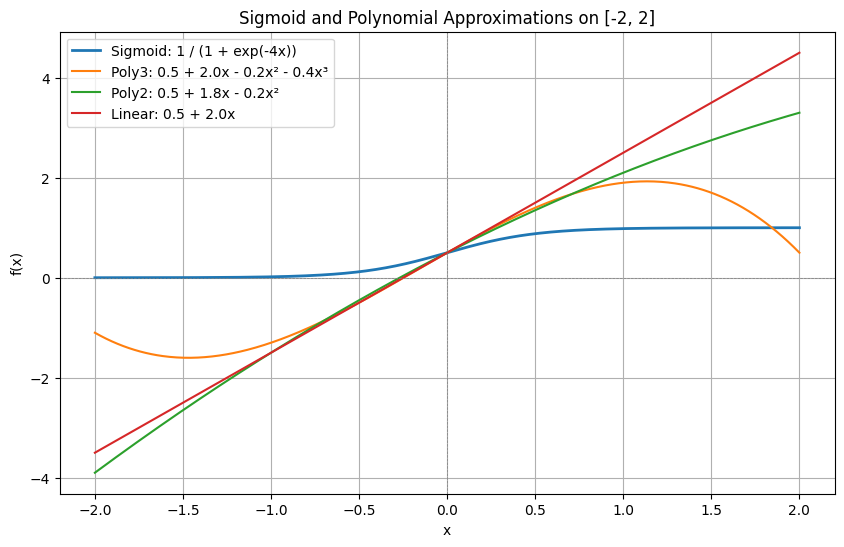

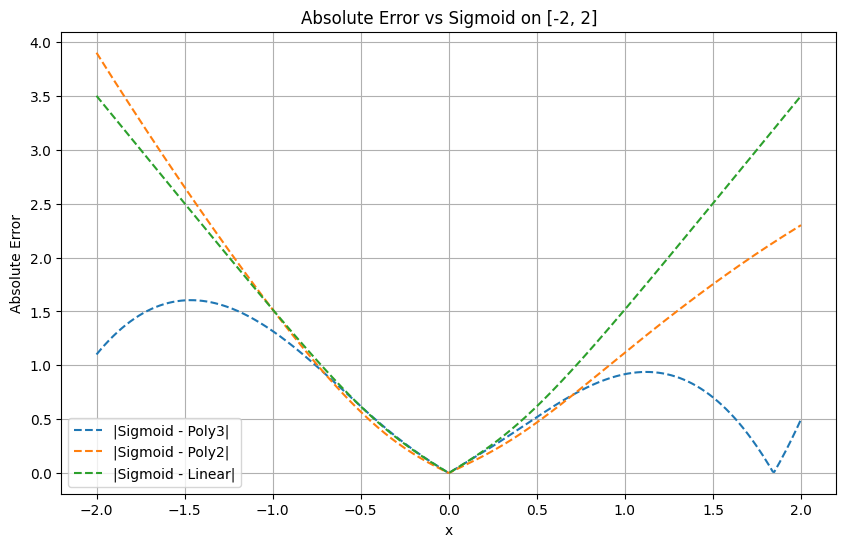

In [156]:
import numpy as np
import matplotlib.pyplot as plt

# Define the x range and sigmoid steepness
x = np.linspace(-2, 2, 500)
steepness = 4

# Define the sigmoid function
sigmoid = 1 / (1 + np.exp(-steepness * x))

# Polynomial approximations
poly3 = 0.5 + 2.0 * x - 0.2 * x**2 - 0.4 * x**3
poly2 = 0.5 + 1.8 * x - 0.2 * x**2
linear = 0.5 + 2.0 * x

# === Plot functions ===
plt.figure(figsize=(10, 6))
plt.plot(x, sigmoid, label='Sigmoid: 1 / (1 + exp(-4x))', linewidth=2)
plt.plot(x, poly3, label='Poly3: 0.5 + 2.0x - 0.2x² - 0.4x³')
plt.plot(x, poly2, label='Poly2: 0.5 + 1.8x - 0.2x²')
plt.plot(x, linear, label='Linear: 0.5 + 2.0x')

plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.title('Sigmoid and Polynomial Approximations on [-2, 2]')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

# === Plot approximation errors ===
error_poly3 = np.abs(sigmoid - poly3)
error_poly2 = np.abs(sigmoid - poly2)
error_linear = np.abs(sigmoid - linear)

plt.figure(figsize=(10, 6))
plt.plot(x, error_poly3, label='|Sigmoid - Poly3|', linestyle='--')
plt.plot(x, error_poly2, label='|Sigmoid - Poly2|', linestyle='--')
plt.plot(x, error_linear, label='|Sigmoid - Linear|', linestyle='--')

plt.title('Absolute Error vs Sigmoid on [-2, 2]')
plt.xlabel('x')
plt.ylabel('Absolute Error')
plt.legend()
plt.grid(True)
plt.show()